# Monthly Mean Net Surface Heat Flux: ACCESS vs Papa
### As part of the flux components, this notebook produces a figure comparing the monthly mean net surface heat flux climatology of three different Access-om2 resolutions versus observational data from PAPA ocean station

In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 1
Total threads: 1,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35977,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32823,Total threads: 1
Dashboard: /proxy/40517/status,Memory: 63.00 GiB
Nanny: tcp://127.0.0.1:43663,


### Inspect PAPA data to identify variable names, latitudes etc.

In [3]:
PAPA_DIR = "/g/data/jk72/ob1561"
papa_lw_file = os.path.join(PAPA_DIR, "qnet50n145w_hr.cdf")

ds_lw = xr.open_dataset(papa_lw_file)

print(ds_lw)
print("\nData variables:", list(ds_lw.data_vars))
print("Coordinates:", list(ds_lw.coords))

print("\Surface heat flux variable details:")
for v in ds_lw.data_vars:
    print(f"\n--- {v} ---")
    print(ds_lw[v])
    print("Attrs:", ds_lw[v].attrs)
    print("Min / max (raw):",
          float(ds_lw[v].min()), float(ds_lw[v].max()))

ds_lw.close()

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 138523, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2010-01-01 ... 2025-10-20T18:00:00
  * depth     (depth) float32 4B 0.0
  * lat       (lat) float32 4B 50.0
  * lon       (lon) float32 4B 215.0
Data variables:
    QT_210    (time, depth, lat, lon) float32 554kB ...
    QQ0_5210  (time, depth, lat, lon) float32 554kB ...
Attributes:
    platform_code:                50n145w
    site_code:                    50n145w
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  OCS Project Office/NOAA/PMEL
    OCS:                          Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                16:32  7-DEC-2025

Data variables: ['QT_210', 

In [4]:
print('Starting ACCESS-OM2 and PAPA net surface heat flux analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri


#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2 
#----------------------------------------------------------------------------------------------

var   =  'net_sfc_heating'
experiments = ['1deg_jra55_iaf_omip2_cycle6', '025deg_jra55_iaf_omip2_cycle6', ['01deg_jra55v140_iaf_cycle4', '01deg_jra55v140_iaf_cycle4_jra55v150_extension']]

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

# Papa
PAPA_DIR = "/g/data/jk72/ob1561"
papa_sfc_file = os.path.join(PAPA_DIR, "qnet50n145w_hr.cdf")
papa_var = "QT_210"

# -------------------------------------------------------------
# Region of interest (unchanged)
# -------------------------------------------------------------
region_lat = np.array([49, 51])      # narrow 2° band around 50°N
region_lon = np.array([213, 217])# xt_ocean, E     # -> [-215, -210]
region_lon = region_lon - 360
region = [region_lat, region_lon]

Starting ACCESS-OM2 and PAPA net surface heat flux analysis.


In [5]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")
    


Processing ACCESS net_sfc_heating data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [6]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    grp = heat_flux.groupby("time.month")
    monthly_mean = grp.mean("time", skipna=True)
    monthly_std  = grp.std("time", skipna=True)
    monthly_n    = grp.count("time")
    monthly_sem  = monthly_std / np.sqrt(monthly_n)
    
    exp_heat_flux[exp] = {
    "monthly_mean": monthly_mean,
    "monthly_sem": monthly_sem
}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()


Start collecting net_sfc_heating 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting net_sfc_heating data for ACCESS.
Execution time: 0.03 minutes
Start collecting net_sfc_heating 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting net_sfc_heating data for ACCESS.
Execution time: 0.04 minutes
Start collecting net_sfc_heating 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting net_sfc_heating data for ACCESS.
Execution time: 0.05 minutes


In [7]:
#--------------------------------------------------------------
# Read and collect data for Papa (latent heat flux)
#--------------------------------------------------------------

print(f'Processing Papa {var} data...')
sys.stdout.flush()

PAPA_DIR = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "qnet50n145w_hr.cdf")

start = time.time()

ds_papa = xr.open_dataset(papa_file)


papa_flux = ds_papa["QT_210"].sel(
    time=slice(start_date, end_date),
    depth=0
)


#papa_flux = papa_flux.where(papa_flux < 1e20)

# Remove lat/lon singleton dims
papa_flux = papa_flux.mean(dim=["lat", "lon"])

ds_papa.close()

# Monthly climatology
papa_monthly_climatology = papa_flux.groupby("time.month").mean(dim="time")

end = time.time()

print("Finished collecting Papa data.")
print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing Papa net_sfc_heating data...
Finished collecting Papa data.
Execution time: 0.00 minutes


In [8]:
#------------------------------------------------------------
# Read and collect data for PAPA (net surface heat flux)
#------------------------------------------------------------

print(f'Processing PAPA {papa_var} data...')
sys.stdout.flush()

# Open the PAPA Qnet file
ds_papa = xr.open_dataset(papa_sfc_file)

papa_sfc = ds_papa[papa_var]
papa_sfc = papa_sfc.where(papa_sfc < 1e30)

grp = papa_sfc.groupby("time.month")

papa_monthly_mean = grp.mean(dim="time", skipna=True)
papa_monthly_std  = grp.std(dim="time", skipna=True)
papa_monthly_n    = grp.count(dim="time")
papa_monthly_sem  = papa_monthly_std / np.sqrt(papa_monthly_n)

ds_papa.close()

print('Finished collecting PAPA data.')
sys.stdout.flush()
print(papa_monthly_climatology)


Processing PAPA QT_210 data...
Finished collecting PAPA data.
<xarray.DataArray 'QT_210' (month: 12)> Size: 48B
array([1.70410914e+34, 1.79957808e+34, 2.30414759e+34, 1.73511917e+34,
       7.04685112e+33, 4.64285729e+33, 9.50460884e+32, 7.96851017e+32,
       1.05158735e+33, 7.40207430e+33, 7.69841300e+33, 9.39093639e+33],
      dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    depth    float32 4B 0.0


Model series available: ['1deg_jra55_iaf_omip2_cycle6', '025deg_jra55_iaf_omip2_cycle6', '01deg_jra55v140_iaf_cycle4']


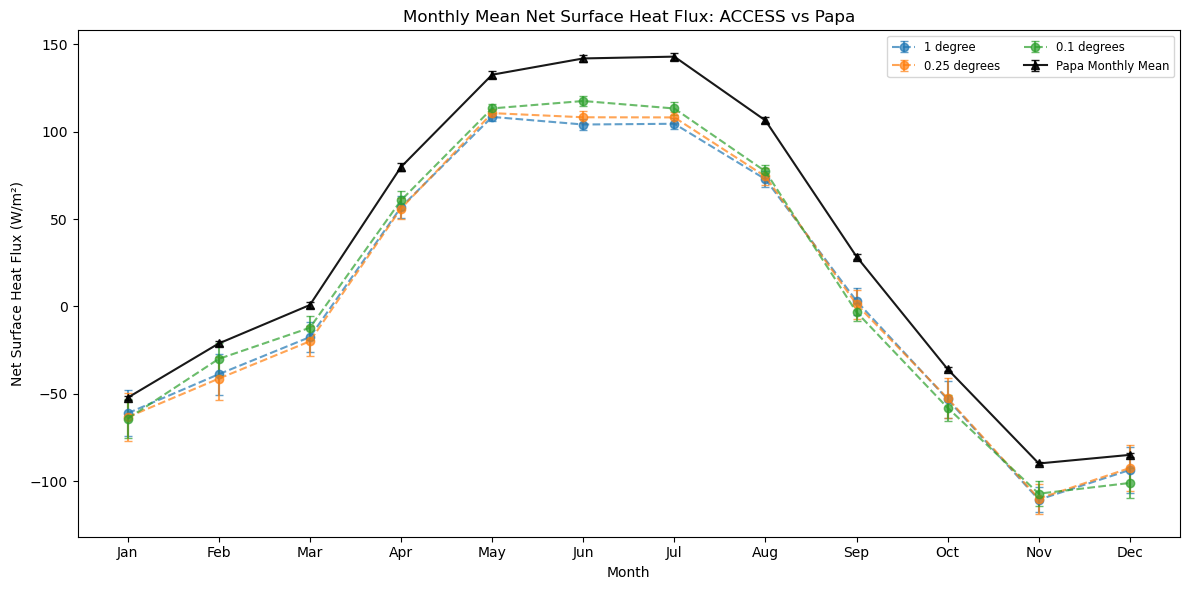

In [9]:
# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

exp_titles = {
    '1deg_jra55_iaf_omip2_cycle6': '1 degree',
    '025deg_jra55_iaf_omip2_cycle6': '0.25 degrees',
    '01deg_jra55v140_iaf_cycle4': '0.1 degrees'
}

# ACCESS curves
print("Model series available:", list(exp_heat_flux.keys()))
for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict["monthly_mean"]
    monthly_sem  = data_dict["monthly_sem"]
    label = exp_titles.get(exp_name, exp_name)

    ax.errorbar(
        monthly_mean["month"],
        monthly_mean.values,
        yerr=monthly_sem.values,
        marker="o",
        linestyle="--",
        alpha=0.7,
        capsize=3,
        label=label
    )

# ----- PAPA net surface heat flux (NO sign flip) -----
# papa_monthly_climatology has dims: (month, depth, lat, lon)
papa_mean_1d = papa_monthly_mean.isel(depth=0, lat=0, lon=0)
papa_sem_1d  = papa_monthly_sem.isel(depth=0, lat=0, lon=0)

ax.errorbar(
    papa_mean_1d["month"],
    papa_mean_1d.values,
    yerr=papa_sem_1d.values,
    color="black",
    marker="^",
    linestyle="-",
    alpha=0.9,
    capsize=3,
    label="Papa Monthly Mean"
)


ax.set_xlabel('Month')
ax.set_ylabel('Net Surface Heat Flux (W/m²)')
ax.set_title('Monthly Mean Net Surface Heat Flux: ACCESS vs Papa')
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
ax.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()


### Quick check of SEM and Mean in the 1 d

In [10]:
import numpy as np

# Pick a representative month, e.g. July = 7
m = 7

# Choose one model run
k = list(exp_heat_flux.keys())[0]
mean_m = float(exp_heat_flux[k]["monthly_mean"].sel(month=m).values)
sem_m  = float(exp_heat_flux[k]["monthly_sem"].sel(month=m).values)

# Recompute n and std directly from the grouped data for that run (no ambiguity)
# (Use the same variable you used to build heat_flux inside the loop, if still available.
# If not, temporarily print n from stored monthly_n if you kept it.)
print("Example run:", k)
print("Month:", m)
print("Mean:", mean_m)
print("SEM :", sem_m)


Example run: 1deg_jra55_iaf_omip2_cycle6
Month: 7
Mean: 104.47669982910156
SEM : 3.152741392066122
